# EDA bộ dữ liệu Rossmann

## 1. Bối cảnh

Rossmann là một trong những chuỗi nhà thuốc – mỹ phẩm (drugstore) lớn nhất châu Âu, hơn 3.000 cửa hàng tại 7 quốc gia. Hiện các quản lý cửa hàng tự dự báo doanh số hằng ngày theo kinh nghiệm, độ chính xác chênh lệch rất lớn giữa người này người kia. Doanh số mỗi cửa hàng chịu tác động của nhiều yếu tố: khuyến mãi, mức độ cạnh tranh xung quanh, ngày lễ (nhà nước / trường học), mùa vụ, và đặc thù địa phương.

> **Yêu cầu:** *Dự báo cột Sales — doanh thu hằng ngày của từng cửa hàng — cho 6 tuần tương lai.*

Đây là bài toán hồi quy trên chuỗi thời gian. Dự báo tốt giúp Rossmann lên lịch nhân sự, quản lý tồn kho và lập kế hoạch khuyến mãi hiệu quả hơn.

**Metric đánh giá:** Root Mean Square Percentage Error (RMSPE)
$$ \text{RMSPE} = \sqrt{\dfrac{1}{n} \sum_{i=1}^{n} \left( \dfrac{y_i - \hat{y}_i}{y_i}\right)^2}.$$
Trong đó, $y_i$ là giá trị đúng và $\hat{y}_i$ là giá trị dự đoán.

**Bảng mô tả cột**

Bảng dữ liệu Doanh thu của mỗi cửa hàng theo ngày (train.csv)

| Cột| Mô tả | 
| ------------- | ------------- | 
| Store           | Mã cửa hàng |
| DayOfWeek       | Thứ trong tuần | 
| Date            | Ngày |
| Sales           | Doanh thu - biến mục tiêu | 
| Customers       | Số lượng khách hàng trong ngày hôm đó |
| Open            | 0/1 đóng/mở |
| Promo           | Có chạy khuyến mãi trong ngày đó hay không | 
| StateHoliday    | Lễ nhà nước (0 không lễ, a lễ công, b Phục sinh, c Giáng sinh) |
| SchoolHoliday   | Ngày đó cửa hàng có bị ảnh hưởng bởi kỳ nghỉ của trường học hay không |

Bảng thông tin cửa hàng

| Cột| Mô tả | 
| ------------- | ------------- | 
| Store                     | Mã cửa hàng |
| StoreType                 | 4 mô hình cửa hàng khác nhau: a/b/c/d | 
| Assortment                | Độ rộng danh mục hàng: a cơ bản, b mở rộng, c đầy đủ |
| CompetitionDistance       | Khoảng cách (mét) tới đối thủ cạnh tranh gần nhất | 
| CompetitionOpenSinceMonth | Tháng đối thủ đó mở cửa |
| CompetitionOpenSinceYear  | Năm đối thủ đó mở cửa |
| Promo2                    | Cửa hàng có tham gia chương trình khuyến mãi dài hạn, lặp lại theo chu kỳ không | 
| Promo2SinceWeek           | Tuần cửa hàng đó bắt đầu tham gia Promo2 |
| Promo2SinceYear           | Năm cửa hàng đó bắt đầu tham gia Promo2 |
| PromoInterval             | Liệt kê các tháng mà mỗi vòng Promo2 được khởi động lại, ví dụ "Jan,Apr,Jul,Oct" nghĩa là cứ tháng 1, 4, 7, 10 lại mở một đợt mới.  |

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_train = pd.read_csv('data/train.csv', dtype={'StateHoliday': str}, parse_dates=['Date'])
df_store = pd.read_csv('data/store.csv')

In [38]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int64         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null  datetime64[us]
 3   Sales          1017209 non-null  int64         
 4   Customers      1017209 non-null  int64         
 5   Open           1017209 non-null  int64         
 6   Promo          1017209 non-null  int64         
 7   StateHoliday   1017209 non-null  str           
 8   SchoolHoliday  1017209 non-null  int64         
dtypes: datetime64[us](1), int64(7), str(1)
memory usage: 69.8 MB


In [39]:
df_train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


## 2. Data Quality Audit

### 2.1 Bảng train

In [40]:
df_train.describe()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1017209,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,2014-04-11 01:30:42.846062,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
min,1.000000e+00,1.000000e+00,2013-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,2013-08-17 00:00:00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,2014-04-02 00:00:00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,2014-12-12 00:00:00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,2015-07-31 00:00:00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00
std,3.219087e+02,1.997391e+00,NaN,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01


#### **a. Kiểm tra tính liên tục của trục thời gian**

In [41]:
# Tạo biến đọc dữ liệu mới dùng riêng cho việc kiểm tra
raw = pd.read_csv('data/train.csv', dtype={'StateHoliday': str}, parse_dates=['Date'])

check_dup = raw[['Date', 'Store']]
check_dup.duplicated().sum()

np.int64(0)

Dữ liệu không có dòng nào bị trùng về cả 'Date' và 'Store', đảm bảo mỗi cửa hàng một ngày chỉ có 1 dòng dữ liệu.

In [42]:
start_date = raw['Date'].min()
end_date = raw['Date'].max()

full_date_range = pd.date_range(start=start_date, end=end_date, freq='D')
missing_date = full_date_range.difference(raw['Date'])
print(missing_date)

DatetimeIndex([], dtype='datetime64[us]', freq='D')


Trên toàn bộ dữ liệu thì không có ngày nào bị ngắt quãng, tuy nhiên đây mới là kiểm tra chung, nếu có một vài cửa hàng thiếu dữ liệu của ngày đó nhưng cửa hàng khác có thì code trên không báo thiếu. Cần kiểm tra kỹ hơn cho từng cửa hàng.

In [43]:
g = raw.groupby('Store')['Date']
sumtb = pd.DataFrame({
    'so_ngay_co_ban_ghi': g.nunique(),
    'so_ngay_theo_lich': (g.max() - g.min()).dt.days + 1,
})
sumtb['thieu'] = sumtb['so_ngay_theo_lich'] - sumtb['so_ngay_co_ban_ghi']
sumtb['thieu'].describe()

count    1115.000000
mean       29.704036
std        67.729809
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       184.000000
Name: thieu, dtype: float64

In [44]:
raw = raw.sort_values(['Store', 'Date'])
raw['gap'] = raw.groupby('Store')['Date'].diff()

per_store = raw.groupby('Store')['gap'].agg(
    max_gap='max',
    so_lan_dut=lambda s: (s > pd.Timedelta('1 days')).sum()
)
per_store['max_gap'].value_counts()

max_gap
1 days      935
185 days    180
Name: count, dtype: int64

In [45]:
big = raw[raw['gap'] > pd.Timedelta('100 days')].copy()
big['ngay_cuoi_truoc_lo'] = big['Date'] - big['gap']
big['ngay_co_lai']        = big['Date']
big[['Store', 'ngay_cuoi_truoc_lo', 'ngay_co_lai', 'gap']].head(10)

,Store,ngay_cuoi_truoc_lo,ngay_co_lai,gap
235277,13,2014-06-30,2015-01-01,185 days
235284,20,2014-06-30,2015-01-01,185 days
235286,22,2014-06-30,2015-01-01,185 days
235296,32,2014-06-30,2015-01-01,185 days
235300,36,2014-06-30,2015-01-01,185 days
235305,41,2014-06-30,2015-01-01,185 days
235310,46,2014-06-30,2015-01-01,185 days
235315,51,2014-06-30,2015-01-01,185 days
235316,52,2014-06-30,2015-01-01,185 days
235322,58,2014-06-30,2015-01-01,185 days


In [46]:
big['ngay_cuoi_truoc_lo'].dt.date.value_counts()


ngay_cuoi_truoc_lo
2014-06-30    180
Name: count, dtype: int64

In [47]:
big['ngay_co_lai'].dt.date.value_counts()

ngay_co_lai
2015-01-01    180
Name: count, dtype: int64

Có đúng 180 cửa hàng không có dữ liệu liên tục trong 184 ngày. Các cửa hàng này đều không có dữ liệu trong cùng một khoảng thời gian, từ sau ngày 2014-06-30 đến trước ngày ngày 2015-01-01. Có thể là nhóm dữ liệu này đã bị loại ra khỏi dữ liệu ban đầu, hoặc do các cửa hàng đóng cửa dài hạn để nâng cấp sửa chữa.

#### **b. Phân tích 1:** 
Bộ dữ liệu bao gồm cả những ngày cửa hàng không mở cửa, vào những ngày này chắc chắn doanh thu sẽ bằng 0. Do đó ta sẽ không đưa những dòng này vào phân tích và huấn luyện mô hình.

In [48]:
df_train[df_train['Open']==0].shape

(172817, 9)

In [49]:
df_train = df_train[df_train['Open'] == 1].copy()
df_train.describe()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday
count,844392.000000,844392.000000,844392,844392.000000,844392.000000,844392.0,844392.000000,844392.000000
mean,558.422920,3.520361,2014-04-11 01:02:42.487564,6955.514291,762.728395,1.0,0.446352,0.193580
min,1.000000,1.000000,2013-01-01 00:00:00,0.000000,0.000000,1.0,0.000000,0.000000
25%,280.000000,2.000000,2013-08-16 00:00:00,4859.000000,519.000000,1.0,0.000000,0.000000
50%,558.000000,3.000000,2014-03-31 00:00:00,6369.000000,676.000000,1.0,0.000000,0.000000
75%,837.000000,5.000000,2014-12-10 00:00:00,8360.000000,893.000000,1.0,1.000000,0.000000
max,1115.000000,7.000000,2015-07-31 00:00:00,41551.000000,7388.000000,1.0,1.000000,1.000000
std,321.731914,1.723689,NaN,3104.214680,401.227674,0.0,0.497114,0.395103


#### **c. Phân tích 2:** 
Sau khi loại những ngày đóng cửa, vẫn còn một số dữ liệu tuy cửa hàng mở cửa nhưng doanh thu bằng 0. Đây là có là lỗi nhập liệu hoặc thực tế cửa hàng mở cửa nhưng không bán được sản phẩm nào. Tuy nhiên do độ đo ta dùng để đánh giá mô hình là RMSPE nên ta sẽ loại luôn những dòng này khỏi dữ liệu huấn luyện, nếu không công thức RMSPE sẽ không xác định.

In [50]:
df_train[df_train['Sales'] == 0].shape

(54, 9)

In [51]:
df_train = df_train[df_train['Sales'] > 0].copy()
df_train.describe()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday
count,844338.000000,844338.000000,844338,844338.000000,844338.000000,844338.0,844338.000000,844338.000000
mean,558.421374,3.520350,2014-04-11 01:08:38.729703,6955.959134,762.777166,1.0,0.446356,0.193578
min,1.000000,1.000000,2013-01-01 00:00:00,46.000000,8.000000,1.0,0.000000,0.000000
25%,280.000000,2.000000,2013-08-16 00:00:00,4859.000000,519.000000,1.0,0.000000,0.000000
50%,558.000000,3.000000,2014-03-31 00:00:00,6369.000000,676.000000,1.0,0.000000,0.000000
75%,837.000000,5.000000,2014-12-11 00:00:00,8360.000000,893.000000,1.0,1.000000,0.000000
max,1115.000000,7.000000,2015-07-31 00:00:00,41551.000000,7388.000000,1.0,1.000000,1.000000
std,321.730861,1.723712,NaN,3103.815515,401.194153,0.0,0.497114,0.395102


### 2.2 Bảng store

In [52]:
df_store.info()

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 87.2 KB


**Phân tích:** Bảng store có rất nhiều giá trị null cần xử lý
- Có 3 cửa hàng thiếu CompetitionDistance, khả năng các cửa hàng này không phát hiện đối thủ cạnh tranh ở gần. Giả định rằng đối thủ cạnh tranh của chúng nằm ở rất xa, ta có thể điền bằng 2 lần giá trị max của cột này.
- Có 351 cửa hàng có cột CompetitionDistance không null, nhưng vẫn thiếu CompetitionOpenSinceMonth/Year, tức là chúng có đối thủ cạnh tranh nhưng không biết mở cửa từ khi nào. Điều này có thể là thiếu xót khi thu thập dữ liệu. Ta có hai hướng để xử lý trường hợp này, một là bỏ luôn 2 cột này, hoặc là tạo thêm 1 cột như một cờ báo thiếu (ta tạo thêm một cột nhị phân, ví dụ CompetitionOpenUnknown, gán 1 cho 354 cửa hàng thiếu và 0 cho phần còn lại). Trước tiên để đơn giản ta sẽ xử lý theo hướng 1.
- Có 354 (`= 3 + 351`) cửa hàng thiếu đồng thời 3 cột Promo2SinceWeek/Year và PromoInterval . Các cửa hàng này trùng khớp với các cửa hàng có Promo2 bằng 0, tức là các cửa hàng không áp dụng chương trình Promo2. Điều này là hợp lý và đúng với thực tế. Để xử lý dữ liệu null, ta sẽ điền 0 vào 2 cột Promo2SinceWeek/Year và điền 'None' vào cột PromoInterval.


In [53]:
max_distance = df_store['CompetitionDistance'].max()
df_store.fillna({'CompetitionDistance':2*max_distance}, axis=0, inplace=True)
df_store.drop(['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear'], axis=1, inplace=True)
df_store.fillna({'Promo2SinceWeek':0, 'Promo2SinceYear':0, 'PromoInterval':'None'}, axis=0, inplace=True)
df_store.isnull().sum()

Store                  0
StoreType              0
Assortment             0
CompetitionDistance    0
Promo2                 0
Promo2SinceWeek        0
Promo2SinceYear        0
PromoInterval          0
dtype: int64

In [54]:
df_store.describe()

,Store,CompetitionDistance,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1115.00000,1115.000000,1115.000000,1115.000000,1115.000000
mean,558.00000,5798.573991,0.512108,12.083408,1030.239462
std,322.01708,10773.253079,0.500078,15.542241,1006.038782
min,1.00000,20.000000,0.000000,0.000000,0.000000
25%,279.50000,720.000000,0.000000,0.000000,0.000000
50%,558.00000,2330.000000,1.000000,1.000000,2009.000000
75%,836.50000,6905.000000,1.000000,22.000000,2012.000000
max,1115.00000,151720.000000,1.000000,50.000000,2015.000000


## 3. EDA dữ liệu

### 3.1 Phân tích doanh thu trung bình theo ngày/tuần/tháng

<Axes: title={'center': 'Doanh thu trung bình của các cửa hàng theo ngày'}, xlabel='Thời gian', ylabel='Doanh thu trung bình'>

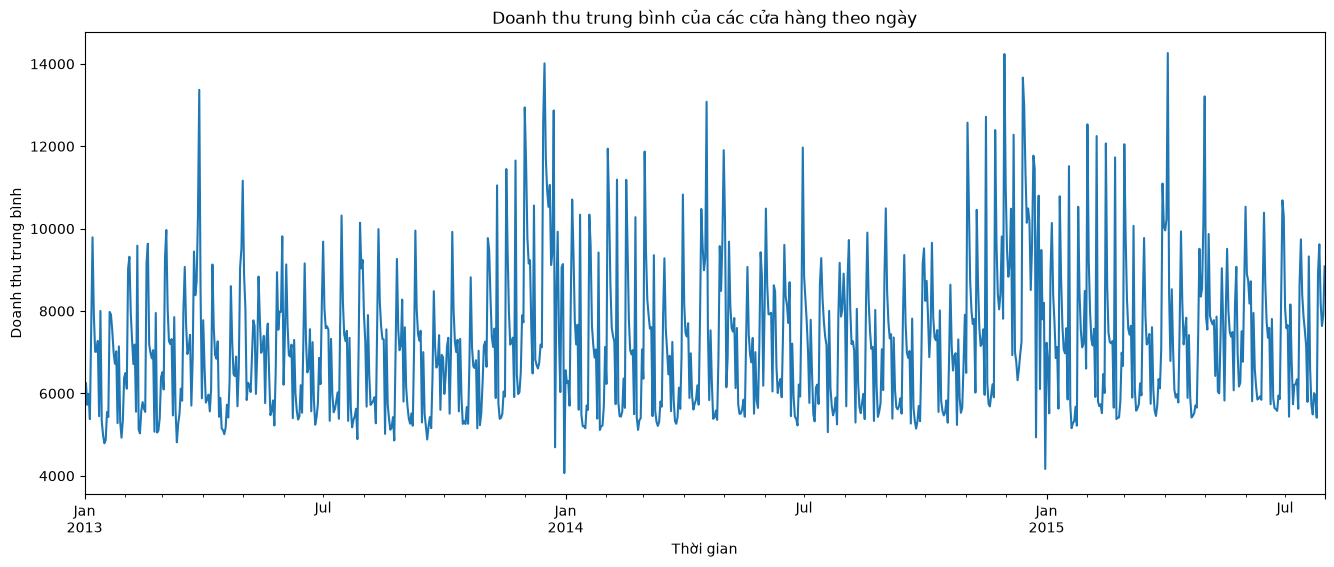

In [55]:
df_train.groupby('Date')['Sales'].mean().plot(title='Doanh thu trung bình của các cửa hàng theo ngày', xlabel='Thời gian', ylabel='Doanh thu trung bình', figsize=(16,6))

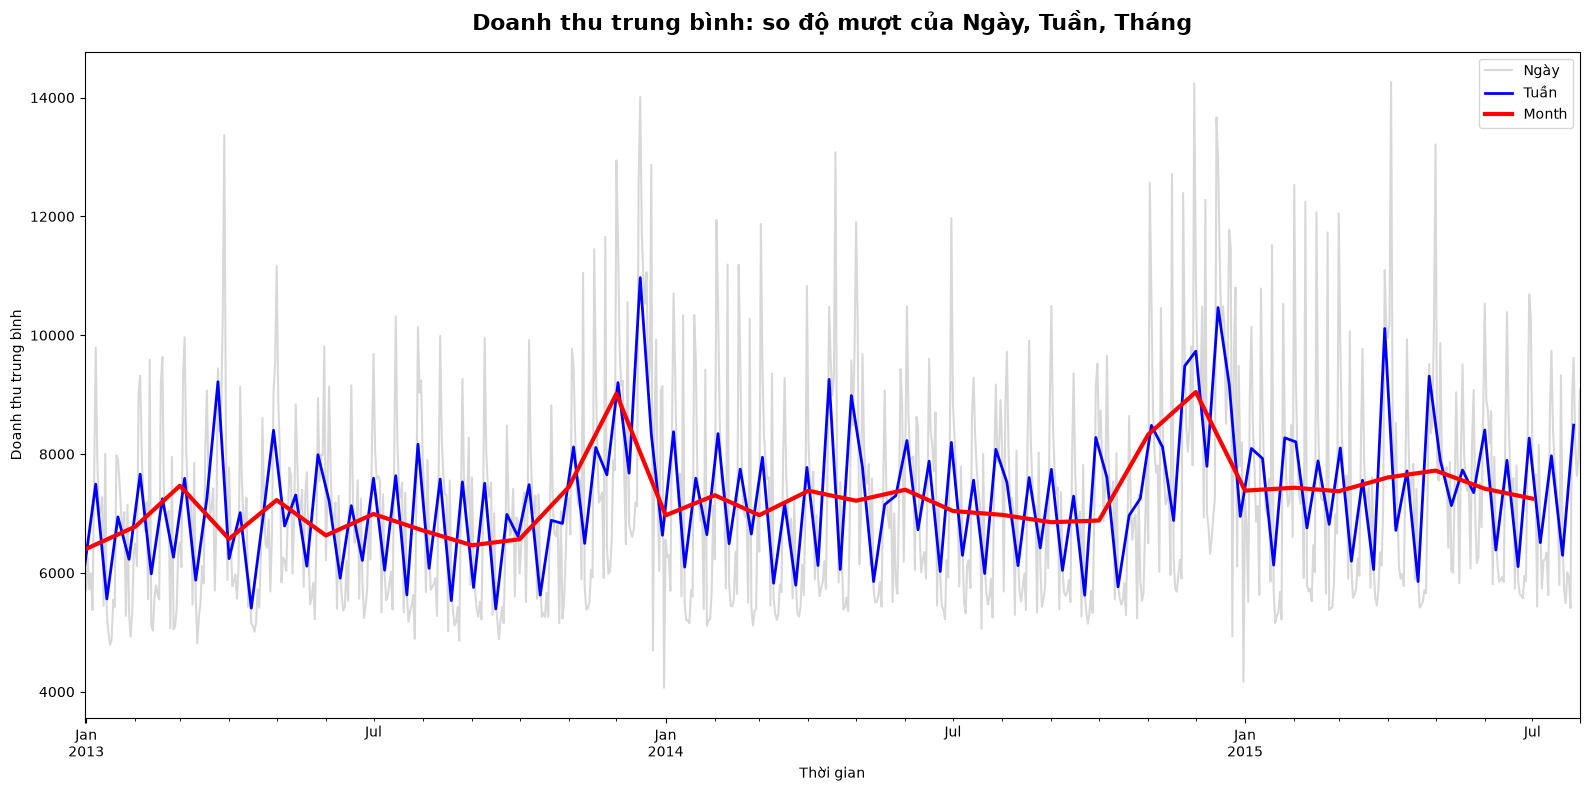

In [56]:
df_daily = df_train.groupby('Date')['Sales'].mean()
df_weekly = df_daily.resample('W').mean()
df_monthly = df_daily.resample('ME').mean()

plt.figure(figsize=(16,8))
df_daily.plot(alpha=0.3, label='Ngày', color='gray')
df_weekly.plot(linewidth=2, label='Tuần', color='blue')
df_monthly.plot(linewidth=3, label='Month', color='red')

plt.title('Doanh thu trung bình: so độ mượt của Ngày, Tuần, Tháng', fontsize=16, fontweight='bold', y=1.02)
plt.ylabel('Doanh thu trung bình')
plt.xlabel('Thời gian')
plt.legend()
plt.tight_layout()
plt.show()

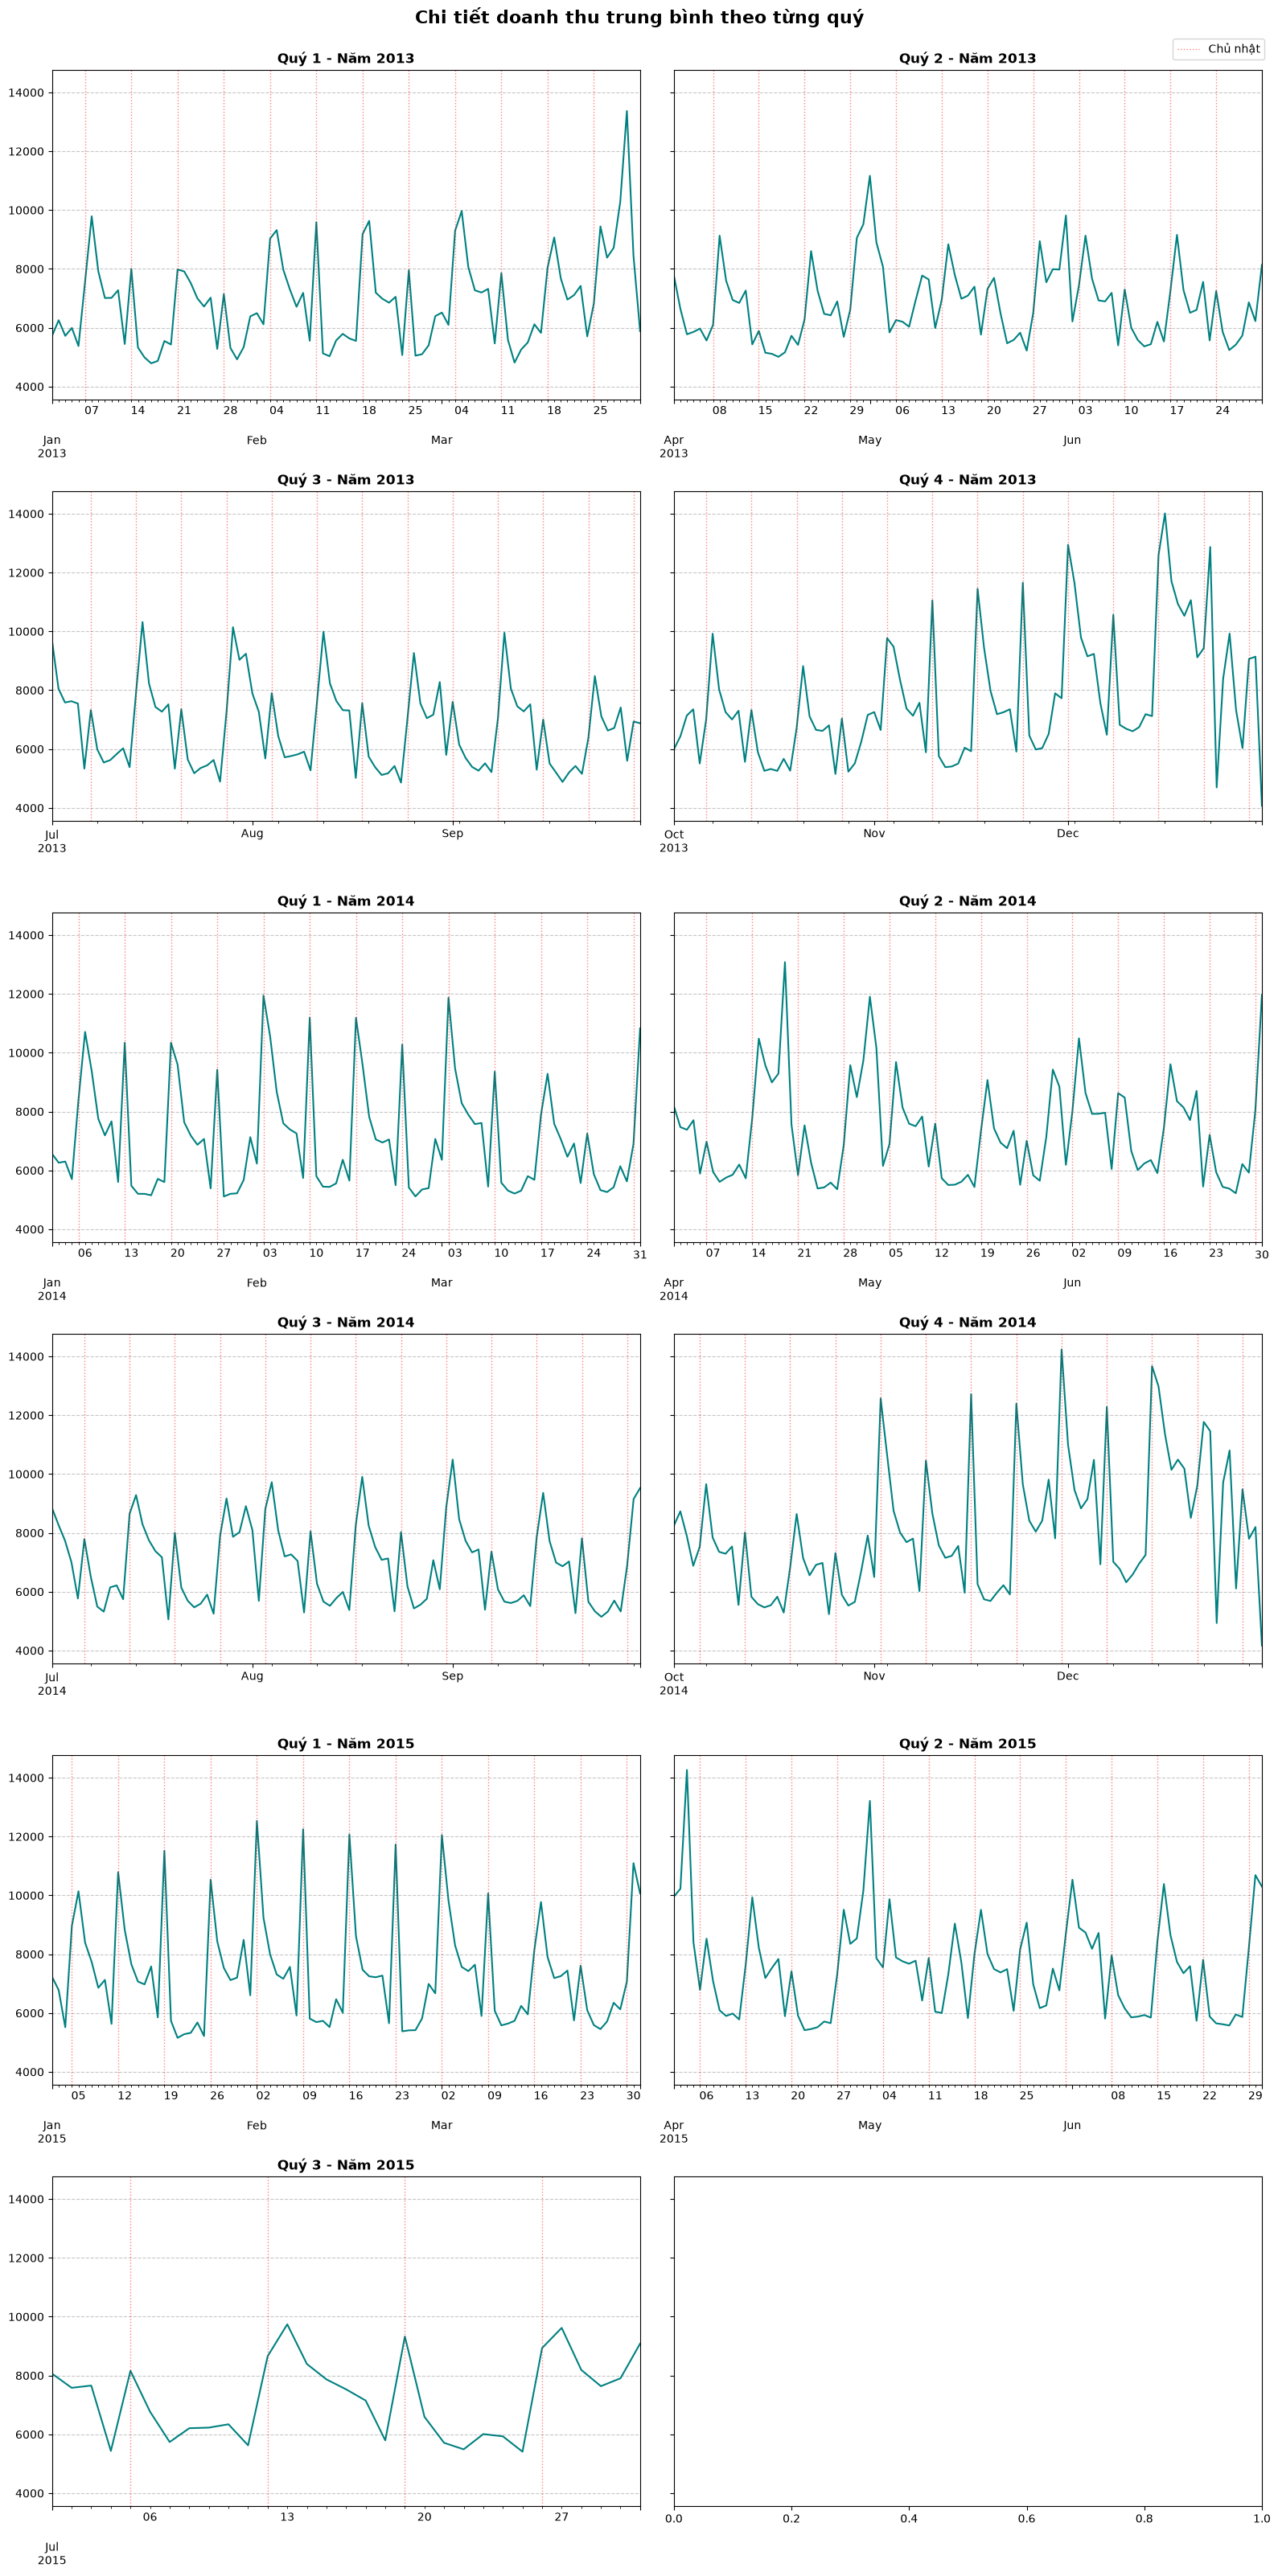

In [57]:
fig, axs = plt.subplots(nrows=6, ncols=2, figsize=(16,32), sharey=True)

axs = axs.flatten()

for i, (q_date, q_data) in enumerate(df_daily.groupby(pd.Grouper(freq='QE'))):
    q_data.plot(ax=axs[i], color='teal')

    axs[i].set_title(f'Quý {q_date.quarter} - Năm {q_date.year}', fontweight='bold')
    axs[i].set_xlabel('')

    axs[i].grid(axis='y', linestyle='--', alpha=0.7)

    sundays = q_data.index[q_data.index.day_of_week == 6]

    for sunday in sundays:
        axs[i].axvline(x=sunday, color='red', linestyle=':', alpha=0.5, linewidth=1)

from matplotlib.lines import Line2D
custom_legend = [Line2D([0], [0], color='red', linestyle=':', alpha=0.5, linewidth=1, label='Chủ nhật')]
fig.legend(handles=custom_legend, loc='upper right', bbox_to_anchor=(0.99, 0.99))

plt.suptitle('Chi tiết doanh thu trung bình theo từng quý', fontsize=16, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

In [58]:
# Lọc ra tất cả các dữ liệu rơi vào ngày 1 tháng 1 (Tết Dương lịch)
ngay_1_1 = df_daily[(df_daily.index.day == 1) & (df_daily.index.month == 1)]
print("Dữ liệu ngày 1/1 các năm:")
print(ngay_1_1)

print("-" * 30)

# Lọc ra tất cả các dữ liệu rơi vào ngày 31 tháng 12 (Đêm giao thừa)
ngay_31_12 = df_daily[(df_daily.index.day == 31) & (df_daily.index.month == 12)]
print("Dữ liệu ngày 31/12 các năm:")
print(ngay_31_12)

Dữ liệu ngày 1/1 các năm:
Date
2013-01-01    5719.705882
2014-01-01    6561.555556
2015-01-01    7231.222222
Name: Sales, dtype: float64
------------------------------
Dữ liệu ngày 31/12 các năm:
Date
2013-12-31    4067.142601
2014-12-31    4166.407487
Name: Sales, dtype: float64


In [59]:
df_train.groupby('DayOfWeek').size()

DayOfWeek
1    137557
2    143955
3    141922
4    134626
5    138633
6    144052
7      3593
dtype: int64

**Nhận xét:**
- Nhìn chung doanh thu trung bình không có xư hướng đi lên hay đi xuống rõ ràng theo thời gian, mà nó có xu hướng đi ngang.
- Doanh thu trung bình trong hai tháng cuối năm (tháng 11 và tháng 12) cao hơn rõ rệt so với các tháng còn lại.
- Doanh thu trung bình chạm đáy vào các ngày cuối cùng của năm (31/12). Điều này phù hợp với thực tế.
- Nếu chỉ nhìn vào biểu đồ ta thấy rất nhiều ngày có doanh thu trung bình cao đều rơi vào chủ nhật, tuy nhiên số cửa hàng mở cửa vào ngày chủ nhật thấp hơn rất nhiều so với số cửa hàng mở cửa vào những ngày khác. Vốn các cửa hàng mở cửa ngày chủ nhật rất đặc biệt, thường là cửa hàng lớn hoặc có vị trí đặc thù. Các cửa hàng này thường có doanh thu cao hơn hẳn những cửa hàng còn lại, đây là selection bias, không thể dùng để so sánh.
- Dựa vào biểu đồ doanh thu trung bình theo tuần, ta thấy một hiện tượng có tính chu kỳ là, thường cứ một tuần có doanh thu trung bình cao sẽ đến một tuần có doanh thu trung bình thấp. Ta cần kiểm tra xem hiện tượng này có bị ảnh hưởng bởi một biến nào đó khác không, hay nó mang tính tự nhiên.

### 3.2 Phân tích ảnh hưởng của Promo đến doanh thu

In [60]:
df_train.groupby('Promo')['Sales'].mean()

Promo
0    5929.826183
1    8228.739731
Name: Sales, dtype: float64

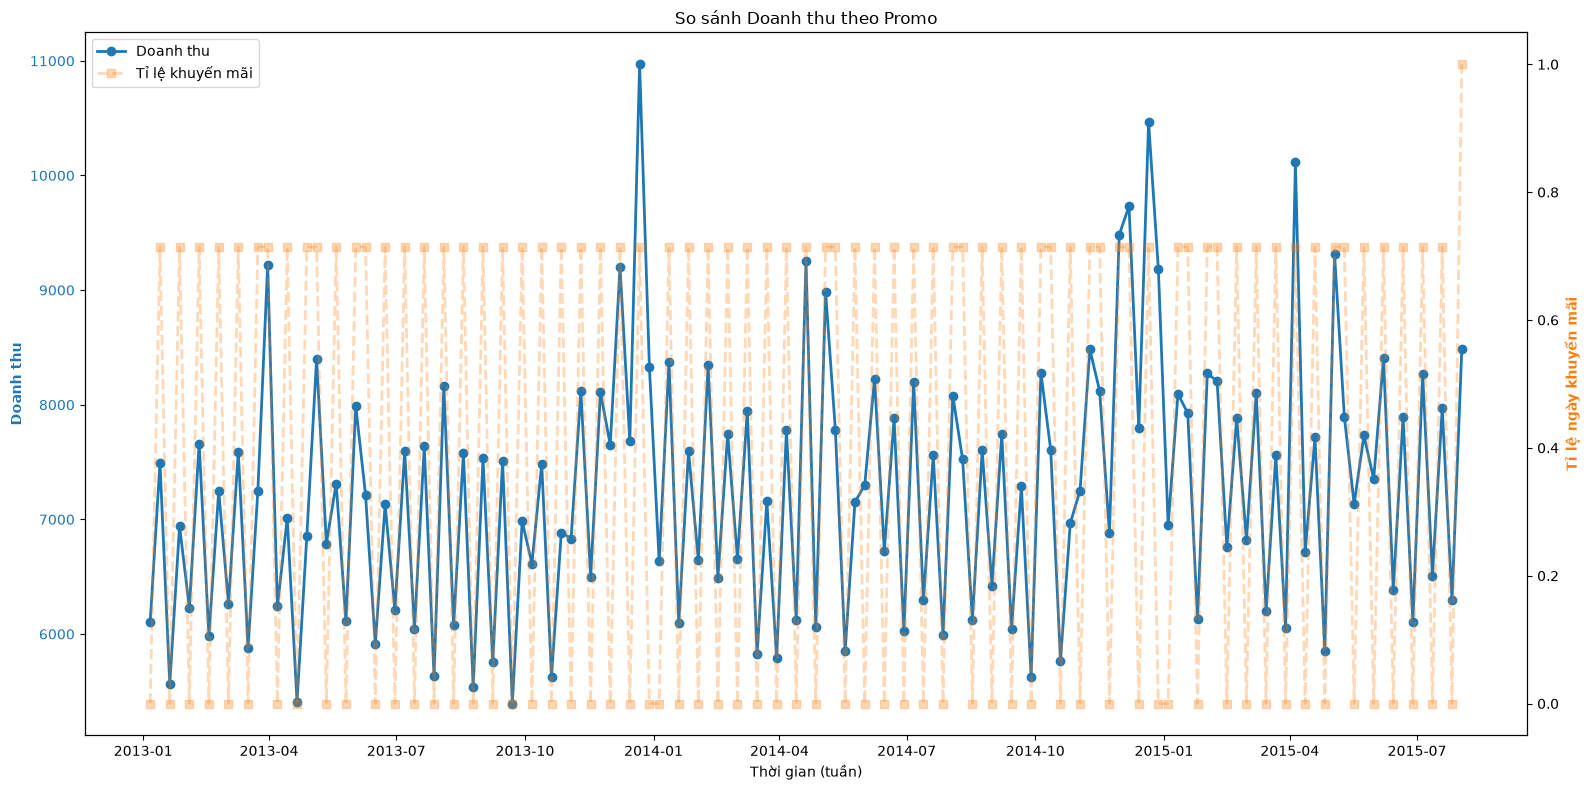

In [61]:
df_daily2 = df_train.groupby('Date')[['Sales', 'Promo']].mean()
df_weekly2 = df_daily2.resample('W').mean()

fig, ax1 = plt.subplots(figsize=(16,8))

color1 = 'tab:blue'
ax1.set_xlabel('Thời gian (tuần)')
ax1.set_ylabel('Doanh thu', color=color1, fontweight='bold')
ax1.plot(df_weekly2.index, df_weekly2['Sales'], color=color1, linewidth=2, marker='o', label='Doanh thu')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()

color2 = 'tab:orange'
ax2.set_ylabel('Tỉ lệ ngày khuyến mãi', color=color2, fontweight='bold')
ax2.plot(df_weekly2.index, df_weekly2['Promo'], color=color2, linewidth=2, marker='s', linestyle='--', label='Tỉ lệ khuyến mãi', alpha=0.3)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.title('So sánh Doanh thu theo Promo')
plt.tight_layout()
plt.show()


In [62]:
df_weekly2['Sales'].corr(df_weekly2['Promo'])

np.float64(0.7234974181933891)

**Nhận xét:** Để ý rằng những tuần có doanh thu trung bình cao sẽ tương ứng với những tuần có tỉ lệ ngày khuyến mãi cao, và ngược lại. Ngoài ra, chênh lệch doanh thu trung bình giữa ngày có khuyến mãi và ngày không có khuyến mãi khá lớn (~2300), và hệ số tương quan giữa doanh thu trung bình và tỉ lệ ngày khuyến mãi cũng khá cao (~0.72). Từ đây ta có thể kết luận, promo có ảnh hưởng lớn đến doanh thu, và tính chu kỳ của doanh thu cũng phần lớn bị ảnh hưởng bởi chu kỳ của promo.

### 3.3 Phân tích ảnh hưởng của ngày lễ đến doanh thu

In [63]:
df_train.groupby('StateHoliday')['Sales'].mean()

StateHoliday
0    6953.960229
a    8487.471182
b    9887.889655
c    9743.746479
Name: Sales, dtype: float64

In [64]:
df_train.groupby('SchoolHoliday')['Sales'].mean()

SchoolHoliday
0    6897.207830
1    7200.710282
Name: Sales, dtype: float64

**Nhận xét:** Các ngày lễ có ảnh hưởng ít nhiều đến doanh thu trung bình, đặc biệt là lễ Phục sinh và lễ Giáng sinh.

### 3.4 Kiểm tra tự tương (autocorrelation)

Vì có một sổ cửa hàng không có dữ liệu vào 6 tháng cuối năm 2014, ta cần chọn ra một dải liên tục để tính lag và kiểm tra tự tương quan được chính xác. Ta sẽ chọn dải dữ liệu của năm 2015.

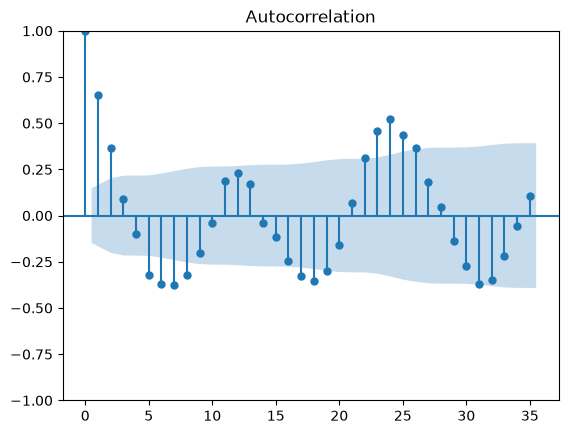

lag 1: 0.6575019382830691
lag 7: -0.3942477258253047
lag 12: 0.24439679132529268


In [65]:
from statsmodels.graphics.tsaplots import plot_acf

df_2015 = df_train[df_train['Date'].dt.year == 2015].copy()
s = df_2015[df_2015['Store'] == 1].set_index('Date').sort_index()['Sales']
plot_acf(s, lags=35)
plt.show()

# đóng đinh bằng số cụ thể:
print('lag 1:', s.autocorr(1))
print('lag 7:', s.autocorr(7))
print('lag 12:', s.autocorr(12))

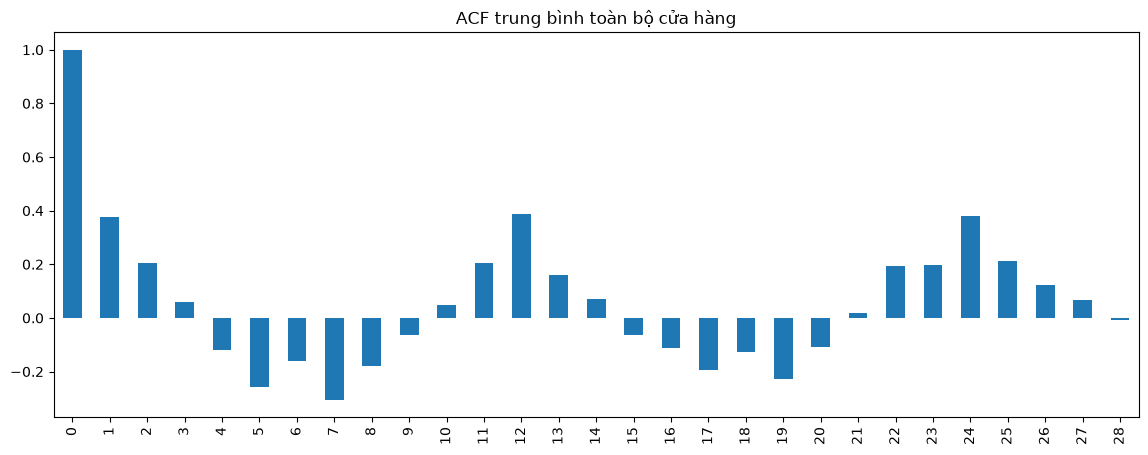

In [66]:
from statsmodels.tsa.stattools import acf

def acf_cua_hang(g, nlags=28):
    s = g.sort_values('Date')['Sales']
    if len(s) > nlags + 1:
        return pd.Series(acf(s, nlags=nlags))
    return None

acf_theo_store = df_2015.groupby('Store').apply(acf_cua_hang)  # dòng = store, cột = lag
acf_trung_binh = acf_theo_store.mean()                     # trung bình qua các cửa hàng
acf_trung_binh.plot(kind='bar', figsize=(14,5), title='ACF trung bình toàn bộ cửa hàng')
plt.show()

**Nhận xét:** 
- Đỉnh dương ở lag_1 (~0.38): doanh thu có quán tính ngày qua ngày, nên tạo lag_1.
- Đỉnh dương ở lag 12 và lag_24 (~0.39): nhịp 2 tuần và 4 tuần, chính là chu kỳ khuyến mãi.
- Vùng âm quanh lag 5-8 (đáy ở lag_7 ~ -0.3): pha ngược của chu kỳ 2 tuần, vì promo tuần có tuần không.

**Lưu ý:** ACF này tính theo dòng ngày mở, không phải theo lịch. Vì đa phần cửa hàng đóng cửa ngày chủ nhật nên lag_6 ~ 1 tuần lịch, lag_12 ~ 2 tuần lịch.

**Kết luận:** Chọn danh sách lag ứng viên: chốt lag 1 (mạnh, rõ) và thử lag_7 để bắt mùa vụ theo tuần. Chu kỳ 2 tuần đã có biến promo gánh, không cần lag riêng. Cần cẩn thận khi tạo lag_7 trong bước tiếp theo, lag_7 chính là doanh thu cùng ngày của tuần trước đó, không phải đếm ngược 7 dòng.

## 4. Gộp và lưu dữ liệu sạch

In [67]:
df_train.shape

(844338, 9)

In [68]:
df = pd.merge(df_train, df_store, how='left', on='Store')
df.shape

(844338, 16)

In [69]:
df.isnull().sum()

Store                  0
DayOfWeek              0
Date                   0
Sales                  0
Customers              0
Open                   0
Promo                  0
StateHoliday           0
SchoolHoliday          0
StoreType              0
Assortment             0
CompetitionDistance    0
Promo2                 0
Promo2SinceWeek        0
Promo2SinceYear        0
PromoInterval          0
dtype: int64

In [70]:
df.to_csv('data/rossmann_cleaned.csv', index=False)
print('Đã lưu dữ liệu sạch vào "data/rossmann_cleaned.csv')

Đã lưu dữ liệu sạch vào "data/rossmann_cleaned.csv


**Nhận xét:** Số dòng dữ liệu sau khi gộp không thay đổi so với trước khi gộp, không có hiện một cửa hàng lặp lại 2 lần trong bảng store. Và sau khi gộp không có dữ liệu null.

## 5. Tổng hợp và kết luận

**Nhận xét:**
- Nhìn chung, doanh thu trung bình của các cửa hàng có xu hướng đi ngang theo thời gian. Doanh thu trung bình tăng cao ở 2 tháng cuối năm và có ảnh hưởng bởi các ngày lễ.
- Doanh thu bị chi phối mạnh bởi các chương trình khuyến mãi, tuần có nhiều ngày áp dụng khuyến mãi sẽ có doanh thu trung bình cao hơn tuần không áp dụng chương trình khuyến mãi.
- Kiểm tra tự tương quan cho thấy lag_1 có tương quan dương cao và lag_7 có tương quan âm, có thể dùng để tạo biến lag trong bước tiếp theo. Lag_2_tuần và lag_4_tuần cũng có tương quan dương cao, điều này trùng với chu kỳ khuyến mãi nên để biến promo gánh, không cần tạo thêm lag riêng.

**Hạn chế:** Chưa phân tích ảnh hưởng của đối thủ cạnh tranh đến doanh thu. Có nhiều cửa hàng thiếu dữ liệu thời gian đối thủ cạnh tranh bắt đầu mở cửa, để đơn giản thì 2 cột dữ liệu này đã bị loại. Sau này nếu cần thiết có thể lấy lại dữ liệu từ hai cột này để phân tích.

**Lưu ý:** Có 180 cửa hàng bị không có dữ liệu doanh thu trong 6 tháng cuối năm 2014. Ngoài ra, bộ dữ liệu cũng đã loại ra các ngày mà cửa hàng không mở cửa và các ngày có doanh thu bằng 0. Lưu ý cho việc tạo biến lag ở bước sau.

**Bước tiếp theo:** Thực hiện Feature engineering, chuẩn bị dữ liệu huấn luyện mô hình.